In [2]:
import numpy as np
import cv2
import os
import glob
import tensorflow
import tensorflow as tf
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2, MobileNetV3Small
from keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from keras_preprocessing.image import ImageDataGenerator
from keras.layers import BatchNormalization, Dense
from keras.regularizers import l1_l2
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
import random
import pickle
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import densenet
from keras.models import Sequential, Model, load_model
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from keras import regularizers
from keras import backend as K
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.utils.np_utils import to_categorical
from sklearn import metrics
tf.config.run_functions_eagerly(True)

In [3]:
pip install emnist
#ran on google collab

In [4]:
from emnist import list_datasets
#extracting the required dataset as 

In [ ]:
#Reducing the training sample to 10 to make it feasible to train and test in terms of RAM and time

In [5]:
from emnist import extract_training_samples
images, labels = extract_training_samples('digits')

In [ ]:
#modified to fit within the ResNet restrictions/requirements

(28, 28)


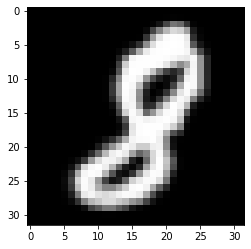

In [6]:
print(images[0].shape)
import cv2
modified_image = cv2.resize(images[0], (32,32), cv2.INTER_LINEAR)
color = cv2.cvtColor(modified_image, cv2.COLOR_GRAY2RGB)
import matplotlib.pyplot as plt
plt.imshow(color, cmap='gray')

In [7]:
print(color.shape)

(32, 32, 3)


In [ ]:
#Setting the color and labelling the images

In [8]:
X = []
y = []
images = images[0:24000]
labels = labels[0:24000]

for image in images:
  modified_image = cv2.resize(image, (32,32), cv2.INTER_LINEAR)
  color = cv2.cvtColor(modified_image, cv2.COLOR_GRAY2RGB)
  X.append(color)
for label in labels:
  y.append(label)

In [9]:
X = np.asarray(X)
y = np.asarray(y)
X = np.squeeze(X)
X.shape

(24000, 32, 32, 3)

In [10]:
X = X/255.0

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5) 

In [12]:
# Hyperparameters
img_height = 32
img_width = 32
batch_size = 32
n_classes = 10
seed = 7

n_points = len(X_train)
nb_validation_samples = len(X_val)

In [13]:
from tensorflow.keras.utils  import to_categorical
y_train = to_categorical(y_train, n_classes)
y_val = to_categorical(y_val, n_classes)
y_test = to_categorical(y_test, n_classes)

In [14]:
print(y_train.shape)

(14400, 10)


In [ ]:
#Building the neccessary model

In [15]:
from tensorflow.keras.applications import ResNet50

def build_model():
    model = Sequential()
    model.add(ResNet50(input_shape=(img_width, img_height,3), include_top=False, pooling='max', weights='imagenet'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dense(n_classes, activation='softmax'))
    
    for layer in model.layers:
        layer.trainable = True

    return model

In [16]:
model = build_model()
opt = Adam(learning_rate=1e-5)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['acc', 'mse'])
print(model.summary())

94781440/94765736 [==============================] - 2s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               25

In [ ]:
#Selecting appropriate number of epochs to get the most accurate result in the most feasible amount of time

In [17]:
from math import ceil
steps_per_epoch = ceil(n_points / batch_size)
epochs = 20
print('Steps Per Epoch:', steps_per_epoch)

Steps Per Epoch: 450


In [18]:
checkpoint_filepath = '/content/'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_acc',
    mode='max', 
    save_best_only = True)

early_stop = EarlyStopping(monitor='val_acc', patience=10, verbose=1, min_delta=1e-4)
reduce_lr = ReduceLROnPlateau(monitor='val_acc', factor=0.1, patience=4, verbose=1, min_delta=1e-4)
callbacks_list = [early_stop, reduce_lr, model_checkpoint_callback]

In [ ]:
#Running the training sample to find out the loss and accuracy

In [19]:
from time import time
start = time()
model_history = model.fit(
    x = X_train, y = y_train,
    epochs=epochs,
    steps_per_epoch = steps_per_epoch,
    validation_data=(X_val, y_val),
    validation_steps=nb_validation_samples // batch_size,
    callbacks=callbacks_list)
end = (time() - start)
print(end)

/usr/local/lib/python3.7/dist-packages/tensorflow/python/data/ops/structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


Epoch 1/20
450/450 [==============================] - 191s 399ms/step - loss: 2.6637 - acc: 0.1526 - mse: 0.0985 - val_loss: 34.2790 - val_acc: 0.1315 - val_mse: 0.1655 - lr: 1.0000e-05
Epoch 2/20
450/450 [==============================] - 170s 378ms/step - loss: 2.0411 - acc: 0.3145 - mse: 0.0818 - val_loss: 3.5738 - val_acc: 0.1873 - val_mse: 0.1033 - lr: 1.0000e-05
Epoch 3/20
450/450 [==============================] - 172s 382ms/step - loss: 1.5854 - acc: 0.4750 - mse: 0.0662 - val_loss: 1.6316 - val_acc: 0.4504 - val_mse: 0.0675 - lr: 1.0000e-05
Epoch 4/20
450/450 [==============================] - 171s 379ms/step - loss: 1.2687 - acc: 0.5969 - mse: 0.0543 - val_loss: 0.9864 - val_acc: 0.7212 - val_mse: 0.0421 - lr: 1.0000e-05
Epoch 5/20
450/450 [==============================] - 171s 381ms/step - loss: 0.9943 - acc: 0.7039 - mse: 0.0430 - val_loss: 0.7109 - val_acc: 0.8285 - val_mse: 0.0300 - lr: 1.0000e-05
Epoch 6/20
450/450 [==============================] - 177s 393ms/step - lo

In [20]:
test_eval = model.evaluate(X_test, y_test, verbose=0)

/usr/local/lib/python3.7/dist-packages/tensorflow/python/data/ops/structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


In [ ]:
#Implementing the test scores

In [21]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.05755919590592384
Test accuracy: 0.987291693687439


In [ ]:
#Plotting Confusion Matrix

/usr/local/lib/python3.7/dist-packages/tensorflow/python/data/ops/structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  "Even though the `tf.config.experimental_run_functions_eagerly` "


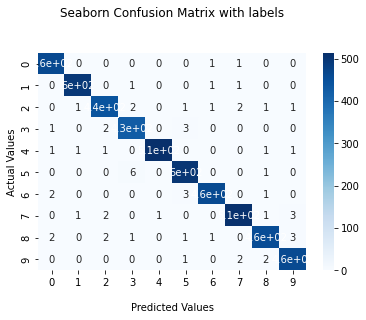

<Figure size 432x288 with 0 Axes>

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

mod_y_pred = []
mod_y_test = []
for pred in y_pred:
    pred = np.argmax(pred)
    mod_y_pred.append(pred)

for test in y_test:
    test = np.argmax(test)
    mod_y_test.append(test)


plt.figure()
cm = confusion_matrix(mod_y_pred, mod_y_test)
ax = sns.heatmap(cm, annot=True, cmap='Blues')
ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values');
plt.savefig('/content/conf_mat.png')
plt.show()

plt.clf()

In [23]:
print(to_categorical(np.argmax(y_pred[0]), num_classes = 10))
print(y_test[0])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [24]:
to_categorical(np.argmax(y_pred[0]), num_classes = 10)

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=float32)

In [25]:
y_test[0]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
#Plotting the training and validation accuracy and loss

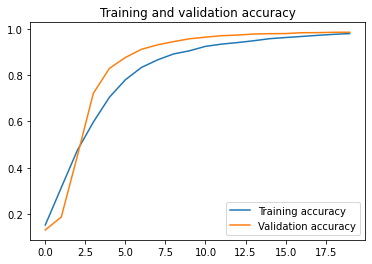

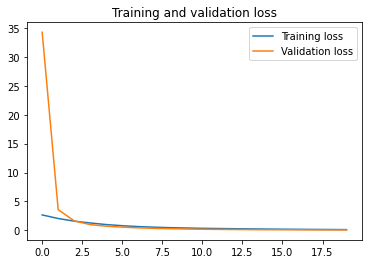

<Figure size 432x288 with 0 Axes>

In [26]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epoch = range(len(acc))
plt.plot(epoch, acc, label='Training accuracy')
plt.plot(epoch, val_acc, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig('/content/acc_curve.png')
plt.figure()
plt.plot(epoch, loss, label='Training loss')
plt.plot(epoch, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig('/content/loss_curve.png')